In [1]:
print("""
@File         : Removing observations with missing data.ipynb
@Author(s)    : Stephen CUI
@LastEditor(s): Stephen CUI
@CreatedTime  : 2025-01-25 15:10:00
@Email        : cuixuanstephen@gmail.com
@Description  : 删除缺失数据的观测值
""")


@File         : Removing observations with missing data.ipynb
@Author(s)    : Stephen CUI
@LastEditor(s): Stephen CUI
@CreatedTime  : 2025-01-25 15:10:00
@Email        : cuixuanstephen@gmail.com
@Description  : 删除缺失数据的观测值



In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [4]:
data = pd.read_csv('../../DATA/credit_approval_uci.csv')
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,target
0,b,30.83,0.00,u,g,w,v,1.25,t,t,1,f,g,202.0,0,1
1,a,58.67,4.46,u,g,q,h,3.04,t,t,6,f,g,43.0,560,1
2,a,24.50,0.50,u,g,q,h,1.50,t,f,0,f,g,280.0,824,1
3,b,27.83,1.54,u,g,w,v,3.75,t,t,5,t,g,100.0,3,1
4,b,20.17,NaN,u,g,w,v,NaN,NaN,NaN,0,f,s,120.0,0,1


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop('target', axis='columns'),
    data['target'], test_size=.3, random_state=42
)

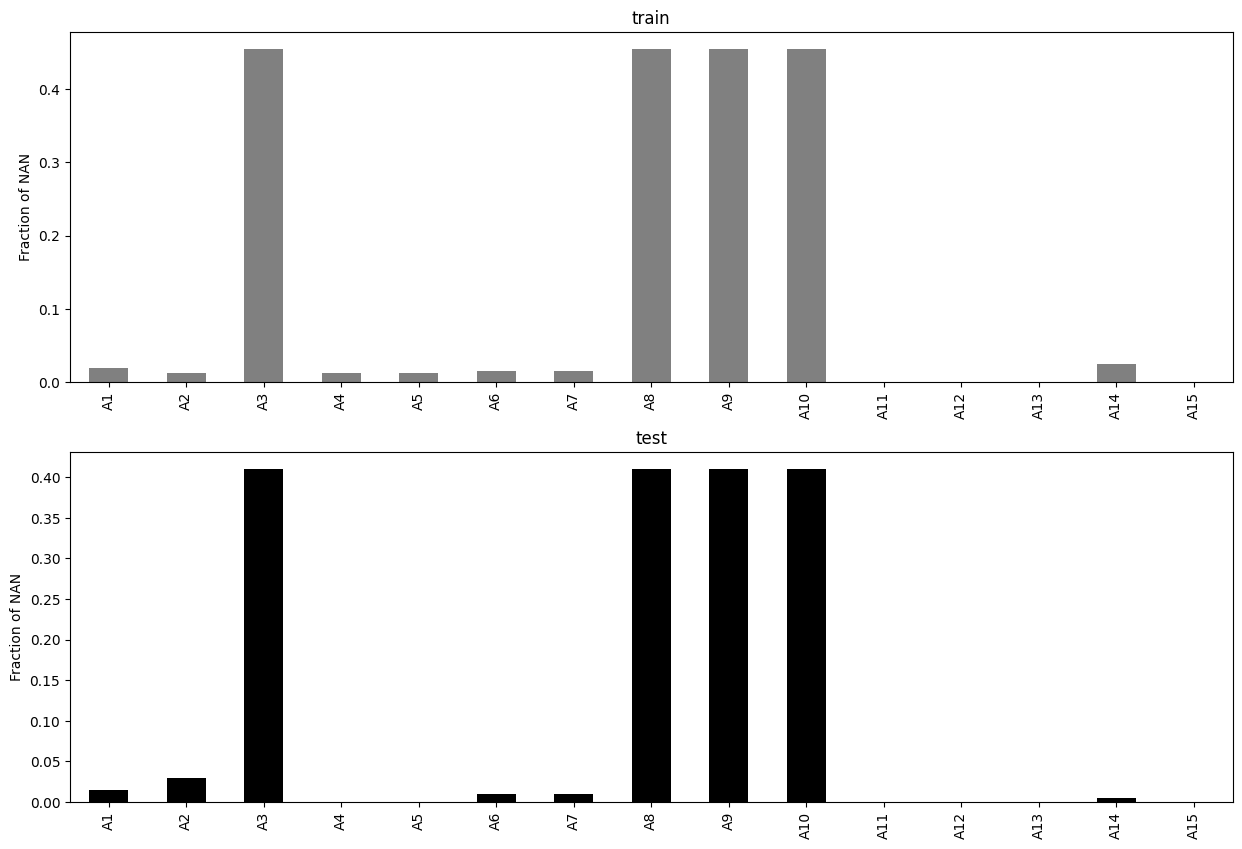

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), squeeze=False)

X_train.isnull().mean().plot(kind='bar', color='grey', ax=axes[0, 0], title='train')
X_test.isnull().mean().plot(kind='bar', color='black', ax=axes[1, 0], title='test')

axes[0, 0].set_ylabel('Fraction of NAN')
axes[1, 0].set_ylabel('Fraction of NAN')

plt.show()

In [11]:
train_cca = X_train.dropna()
test_cca = X_test.dropna()

> pandas 的 `dropna()` 默认删除任何缺失值的观测值。我们可以像这样删除变量子集中缺失数据的观测值：`data.dropna(subset=["A3", "A4"])`。

In [12]:
print(f'Total observations: {len(X_train)}')
print(f'Observations without NAN: {len(train_cca)}')

Total observations: 483
Observations without NAN: 249


In [13]:
y_train_cca = y_train.loc[X_train.index]
y_test_cca = y_test.loc[X_test.index]

In [14]:
from feature_engine.imputation import DropMissingData

In [15]:
cca = DropMissingData(variables=None, missing_only=True)

In [16]:
cca.fit(X_train)

DropMissingData()

This imputer automatically identified and stored the variables with missing data from the train set when we called the `fit()` method. With the `transform()` method, the imputer removed observations with `nan` in those variables. With `transform_x_y()`, the imputer removed rows with nan from the data sets and then realigned the target variable.

In [17]:
cca.variables_

['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A14']

In [18]:
train_cca = cca.transform(X_train)
test_cca = cca.transform(X_test)

DropMissingData 可以在删除缺失数据后自动调整目标 `target`：

In [19]:
train_cca, y_train_cca = cca.transform_x_y(X_train, y_train)
test_cca, y_test_cca = cca.transform_x_y(X_test, y_test)

要删除变量子集中缺失数据的观测值，请使用 `DropMissingData(variables=["A3", "A4"])`。要删除至少 5% 变量为 `nan` 的行，请使用 `DropMissingData(threshold=0.95)`。